# **Loading data**

In [1]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks
pd.options.plotting.backend = 'plotly' # setting plotly as the backend for pandas plotting 

# loading a soil spectral dataset based on X-ray fluorescence (XRF)

data_complete = pd.read_csv('XRF_databases/soil/plsda/soil.csv', sep=';') 
data = data_complete.loc[:, '1':'15']
target = 'exCa'
data.insert(0, target, data_complete[target])  # inserting the target variable (e.g., exCa (exchangeable calcium))

# PLS **Regression case**

In [2]:
# splitting the data into calibration and prediction sets by kennard-stone algorithm
datacal_reg, datapred_reg = ks.train_test_split(data, test_size=0.25)
Xcalreg = datacal_reg.iloc[:, 1:].reset_index(drop=True)
ycalreg = datacal_reg.loc[:, target].reset_index(drop=True)
Xpredreg = datapred_reg.iloc[:, 1:].reset_index(drop=True)
ypredreg = datapred_reg.loc[:, target].reset_index(drop=True)

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-03 15:52:37,695 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-03 15:52:37,738 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [3]:
# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

Xcalreg_prep, mean_calreg, mean_calreg_poisson  = prepr.poisson(Xcalreg, mc=True)
Xpredreg_prep = ((Xpredreg/np.sqrt(mean_calreg)) - mean_calreg_poisson)

In [4]:
from modeling import pls_optimized

plsr_results = pls_optimized(Xcalreg_prep, ycalreg, 
                             LVmax=4, 
                             Xpred=Xpredreg_prep,
                             ypred=ypredreg,
                             aim='regression',
                             cv=10)
plsr_results[0]

,LVs,R2_Cal,r2_Cal,RMSEC,R2_CV,r2_Cv,RMSECV,RPD_CV,RPIQ_CV,Bias_CV,...,r2_Pred,RMSEP,RPD_Pred,RPIQ_Pred,Bias_Pred,tbias_Pred,X_Cum_Exp_Var,Y_Cum_Exp_Var,X_Ind_Exp_Var,Y_Ind_Exp_Var
0,1,0.656883,0.656883,1.051658,0.622770,0.623123,1.102696,1.633304,2.217293,-0.002055,...,0.450342,1.150487,1.257410,1.721011,-0.436808,2.959459,22.692968,11.941667,22.692968,11.941667
1,2,0.736333,0.736333,0.921893,0.651480,0.664269,1.059904,1.699246,2.306812,-0.005960,...,0.728276,0.880903,1.642216,2.247694,-0.334291,2.957763,43.587589,13.386025,20.894621,1.444358
2,3,0.745287,0.745287,0.906106,0.634746,0.658008,1.085052,1.659864,2.253349,-0.012925,...,0.794095,0.797528,1.813896,2.482671,-0.255070,2.434145,71.133516,13.548790,27.545927,0.162765
3,4,0.769532,0.769532,0.861903,0.625823,0.661211,1.098225,1.639954,2.226319,-0.035702,...,0.823721,0.755711,1.914269,2.620051,-0.302328,3.147724,80.643752,13.989554,9.510235,0.440764


In [5]:
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_cuts = [
('background1', 1.0, 1.33),
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('P', 1.87, 2.10),
('background2', 2.11, 2.19),
('S', 2.20, 2.44),
('background3', 2.45, 2.55),
('Rh L + Ar', 2.56, 3.10),
('background4', 3.11, 3.21),
('K', 3.22, 3.42),
('background5', 3.43, 3.53),
('Ca ka', 3.54, 3.84),
('Ca kb', 3.92, 4.14),
('background6', 4.15, 4.37),
('Ti ka', 4.38, 4.66),
('background7', 4.67, 4.75),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.02),
('background8', 6.03, 6.13),
('Fe ka', 6.14, 6.68),
('background9', 6.69, 6.80),
('Fe kb', 6.81, 7.30),
('background10', 7.31, 7.91),
('Cu', 7.92, 8.20),
('background11', 8.21, 10.69),
('Fe ka + Ti ka', 10.7, 11.14),
('background12', 11.15, 12.55),
('sum Fe', 12.56, 13.1),
('background13', 13.11, 15.0)]

import explaining as exp

spectral_zones = exp.extract_spectral_zones(Xcalreg_prep, spectral_cuts) # extracting the spectral zones
spectral_zones['Ca ka'].T.plot(title='spectral zone') # plotting the Al ka spectral zone

In [6]:
plsr_results[4].T.plot() # VIP scores plot


In [7]:
import numpy as np
import pandas as pd

# vip
vip_scores_df = pd.DataFrame({
    'energy' : plsr_results[4].T.index,
    'VIP_Score' : plsr_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# reg vet
reg_vet = pd.DataFrame(plsr_results[3].coef_, columns=plsr_results[3].feature_names_in_) # creating a DataFrame with regression coefficients
reg_vet = reg_vet.T
reg_vet.insert(0, 'energy', reg_vet.index) # adding energy column
reg_vet = reg_vet.reset_index(drop=True)
reg_vet.columns = ['energy', 'Reg_coef'] # renaming
reg_vet['Abs_Reg_coef'] = reg_vet['Reg_coef'].abs() # adding absolute value column
reg_vet = reg_vet.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True) # sorting by absolute value

# gerando uma nova coluna em reg_vet com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_reg = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
    for i in reg_vet['energy']: # iterando sobre cada valor de energia no reg_vet
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_reg[i] = zone_name
reg_vet['Zone'] = reg_vet['energy'].map(energy_to_zone_reg) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_reg
reg_vet

# vamos filtrar reg_vet para manter apenas as zonas espectrais únicas com maior valor absoluto do coeficiente de regressão
reg_vet_unique_df = reg_vet.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
reg_vet_unique_df = reg_vet_unique_df.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True)
vip_scores_unique_df

,energy,VIP_Score,Zone
0,3.7,8.863957,Ca ka
1,6.42,4.290818,Fe ka
2,5.9,2.105856,Mn
3,4.02,2.092036,Ca kb
4,7.08,1.586506,Fe kb
5,1.48,1.448375,Al
6,3.3,1.271993,K
7,4.56,1.005294,Ti ka
8,2,0.852290,P
9,1.74,0.719045,Si


In [8]:
# calculando a covariancia relacionando cada variável espectral com a predição do modelo PLS-R
global_cov = np.abs(np.cov(Xcalreg_prep.T, plsr_results[1].iloc[:,-1]))[:-1, -1]  # covariance between each spectral variable and the PLS-R predictions
global_cov_df = pd.DataFrame(global_cov, index=Xcalreg_prep.columns, columns=['Cov'])#.sort_values(by='Cov Score', ascending=False)
global_cov_df.plot()

In [9]:
global_cov_df = pd.DataFrame({
    'energy' : plsr_results[4].T.index,
    'Cov' : global_cov_df['Cov']
	})

global_cov_df = global_cov_df.sort_values(by='Cov', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in global_cov_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
global_cov_df['Zone'] = global_cov_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
global_cov_unique_df = global_cov_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
global_cov_unique_df = global_cov_unique_df.sort_values(by='Cov', ascending=False).reset_index(drop=True)
global_cov_unique_df

,energy,Cov,Zone
0,3.7,1.565469,Ca ka
1,6.4,0.604670,Fe ka
2,4.02,0.360013,Ca kb
3,5.9,0.268458,Mn
4,7.08,0.222433,Fe kb
5,1.48,0.209246,Al
6,3.3,0.172323,K
7,2,0.118232,P
8,12.82,0.086060,sum Fe
9,1.78,0.077749,Si


In [10]:
zone_df = exp.aggregate_spectral_zones(spectral_zones, aggregator='max')
zone_df

,background1,Al,Si,P,background2,S,background3,Rh L + Ar,background4,K,...,Fe ka,background9,Fe kb,background10,Cu,background11,Fe ka + Ti ka,background12,sum Fe,background13
0,0.080885,0.351341,0.465357,0.105475,0.089589,0.021509,0.024889,0.103191,0.023461,-0.058684,...,0.055518,0.067997,0.032207,0.151589,0.208878,0.153319,0.080828,0.085963,0.066376,0.119131
1,0.081353,0.004737,0.052866,0.065927,0.079593,0.082753,0.079118,0.076196,0.023461,0.188094,...,0.856249,-0.007402,0.335918,0.005483,-0.095154,0.021430,0.146195,0.053771,0.045926,0.092278
2,0.104800,0.115763,0.030992,0.121341,0.028641,0.053675,0.016949,0.116240,0.036489,0.032436,...,1.208090,-0.015451,0.453949,0.057908,0.087873,0.057011,0.048351,0.080965,0.102756,0.138687
3,0.075795,0.050371,-0.083555,0.156755,0.062875,0.132163,0.083308,0.059358,0.036489,0.173999,...,1.099776,0.111268,0.386282,0.062618,0.119485,0.063356,0.011127,0.088479,0.272922,0.098724
4,0.098659,0.304643,-0.013481,0.016693,0.018655,0.072838,0.071603,0.085466,0.075770,0.082264,...,1.150918,0.027658,0.468658,0.078244,0.103202,0.071099,0.144100,0.094340,0.199112,0.121788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,0.094049,0.178494,0.084752,0.013862,0.062875,0.062337,0.064930,0.086709,0.081049,-0.017094,...,2.607594,0.138792,0.983938,0.177103,0.115552,0.199662,0.157642,0.164572,0.358420,0.199410
155,0.120757,0.070844,0.152680,0.080369,0.072902,0.114052,0.104971,0.178481,0.027577,0.128733,...,1.476719,0.004231,0.540178,0.016684,-0.021878,0.040687,0.163427,0.067931,0.089084,0.128619
156,0.166373,0.174541,0.387006,0.132930,0.059600,0.071256,0.211747,0.062747,0.042185,-0.015735,...,-0.073194,-0.026350,-0.044232,0.186568,0.253294,0.199021,0.163745,0.183436,0.163041,0.131494
157,0.102395,0.385067,0.682375,0.138949,0.066788,0.153314,0.149759,0.060290,0.108620,0.057849,...,2.929726,0.261119,1.111009,0.168186,0.412841,0.236452,0.244213,0.255486,0.492520,0.336632


In [11]:
# vamos calcular agora a covariancia entre as zonas espectrais e a predição do modelo PLS-R
# usando as zonas agregadas já calculadas em 'zone_sums_df'
zone_cov_scores = []
for zone in zone_df.columns:
    cov_score = np.abs(np.cov(zone_df[zone].values, plsr_results[1].iloc[:,-1].values))[0, 1]  # covariância entre a zona espectral agregada e as predições do PLS-R
    zone_cov_scores.append(cov_score)
zone_cov_scores_df = pd.DataFrame({
    'Zone': zone_df.columns,
    'Cov_Score': zone_cov_scores
})

zone_cov_scores_df = zone_cov_scores_df.sort_values(by='Cov_Score', ascending=False).reset_index(drop=True)
zone_cov_scores_df
# a mediana é o melhor agregador para covariancia

,Zone,Cov_Score
0,Ca ka,1.142404
1,Fe ka,0.409178
2,Ca kb,0.256015
3,Mn,0.180696
4,Fe kb,0.154540
5,K,0.122589
6,Al,0.093809
7,P,0.083584
8,Si,0.061959
9,sum Fe,0.047015


In [12]:
# calculando a mutual information relacionando cada variável espectral com a predição do modelo PLS-DA
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
global_mi_scores = mutual_info_regression(Xcalreg_prep, 
                                    plsr_results[1].iloc[:,-1], # using the continuous predictions from LV=3
                                    discrete_features=False,
                                    n_neighbors=10,
                                    random_state=None)
global_mi_scores_df = pd.DataFrame(global_mi_scores, index=Xcalreg_prep.columns, columns=['MI Score'])#.sort_values(by='MI Score', ascending=False)
global_mi_scores_df.plot()

In [13]:
# vamos calcular agora a mutual information entre as zonas espectrais agregadas e a predição do modelo PLS-R
zone_mi_scores = []
for zone in zone_df.columns:
    # mutual_info_regression expects 2D X (samples × features) and 1D y
    X_zone = zone_df[zone].values.reshape(-1, 1)
    y_pred = plsr_results[1].iloc[:, -1].values  # using the continuous predictions from LV=3
    mi_score = mutual_info_regression(X_zone,
                                     y_pred,
                                     discrete_features=False,
                                     n_neighbors=10,
                                     random_state=None)
    # mi_score is an array (one value per feature), take the first element
    zone_mi_scores.append(float(mi_score[0]))

zone_mi_scores_df = pd.DataFrame({
    'Zone': zone_df.columns,
    'Mi_Score': zone_mi_scores
})
zone_mi_scores_df = zone_mi_scores_df.sort_values(by='Mi_Score', ascending=False).reset_index(drop=True)
zone_mi_scores_df

,Zone,Mi_Score
0,Ca ka,0.643481
1,Ca kb,0.475228
2,K,0.256352
3,Al,0.213841
4,P,0.193561
5,Mn,0.192205
6,background10,0.117095
7,sum Fe,0.094283
8,background1,0.094198
9,background9,0.065946


In [14]:
def predicates_by_quantile(zone_sums_df, quantiles):
    """
    Generate predicates based on specified quantiles for each column in a DataFrame
    and create a predicate indicator matrix.
    
    Parameters
    ----------
    - **zone_sums_df** : pd.DataFrame
        DataFrame with summed values for spectral zones.
    - **quantiles** : list of float
        List of quantiles (between 0 and 1) to generate predicates for.
    
    Returns
    -------
    - **predicates_df** : pd.DataFrame
        DataFrame containing the generated predicates with columns:
        'predicate', 'rule', 'zone', 'thresholds', 'operator'.
    - **predicate_indicator_df** : pd.DataFrame
        Binary indicator matrix (samples × predicates) where 1 indicates
        the sample satisfies the predicate, 0 otherwise.
    """
    import pandas as pd
    import numpy as np

    # calculating the quantiles for each column of zone_sums_df
    zone_quantiles = zone_sums_df.quantile(quantiles)
    
    zone_predicate_list = []
    predicate_num = 1
    for zone in zone_sums_df.columns:
        for q in quantiles:
            q_value = zone_quantiles.loc[q, zone]
            # <= Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} <= {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': "<="
            })
            predicate_num += 1
            # > Q
            zone_predicate_list.append({
                'predicate': f'P{predicate_num}',
                'rule': f"{zone} > {q_value:.2f}",
                'zone': zone,
                'thresholds': f"{q_value:.2f}",
                'operator': ">"
            })
            predicate_num += 1
    
    predicates_df = pd.DataFrame(zone_predicate_list)
    
    # Removing duplicate predicates based on 'rule' column
    # Some zones may have the same quantile values, creating duplicate rules
    initial_count = len(predicates_df)
    predicates_df = predicates_df.drop_duplicates(subset=['rule'], keep='first').reset_index(drop=True)
    final_count = len(predicates_df)
    
    if initial_count != final_count:
        print(f"Removed {initial_count - final_count} duplicate predicates. Remaining: {final_count}")
    
    # Renumbering predicates after removing duplicates
    predicates_df['predicate'] = [f'P{i+1}' for i in range(len(predicates_df))]
    
    # Generating the predicate indicator DataFrame
    
    # function to evaluate a predicate for a given value
    def eval_predicate(value, thresholds, operator):
        if operator == "<=":
            return float(value <= float(thresholds))
        elif operator == ">":
            return float(value > float(thresholds))
        else:
            return np.nan
    
    # compute all columns first, then concatenate them at once
    columns_dict = {}
    
    # iterating over each predicate
    for _, row in predicates_df.iterrows():
        pred = row['predicate']
        zone = row['zone']
        thresholds = row['thresholds']
        operator = row['operator']
        columns_dict[pred] = zone_sums_df[zone].apply(
            lambda v: eval_predicate(v, thresholds, operator)
        ).astype(int)
    
    # create DataFrame from all columns at once
    predicate_indicator_df = pd.DataFrame(columns_dict, index=zone_sums_df.index)
    
    # setting column names to rules for better readability
    predicate_indicator_df.columns = predicates_df['rule'].tolist()
    
    # computing co-occurrence matrix
    co_occurrence_matrix = np.dot(predicate_indicator_df.T, predicate_indicator_df)
    co_occurrence_matrix_df = pd.DataFrame(co_occurrence_matrix, index=predicate_indicator_df.columns, columns=predicate_indicator_df.columns) 

    return predicates_df, predicate_indicator_df, co_occurrence_matrix_df

predicates_quantiles = predicates_by_quantile(zone_df, [0.25, 0.5, 0.75]) # getting predicates for quartiles


In [15]:
predicates_quantiles[1]

,background1 <= 0.07,background1 > 0.07,background1 <= 0.09,background1 > 0.09,background1 <= 0.11,background1 > 0.11,Al <= 0.06,Al > 0.06,Al <= 0.12,Al > 0.12,...,sum Fe <= 0.15,sum Fe > 0.15,sum Fe <= 0.20,sum Fe > 0.20,background13 <= 0.11,background13 > 0.11,background13 <= 0.14,background13 > 0.14,background13 <= 0.17,background13 > 0.17
0,0,1,1,0,1,0,0,1,0,1,...,1,0,1,0,0,1,1,0,1,0
1,0,1,1,0,1,0,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0
2,0,1,0,1,1,0,0,1,1,0,...,1,0,1,0,0,1,1,0,1,0
3,0,1,1,0,1,0,1,0,1,0,...,0,1,0,1,1,0,1,0,1,0
4,0,1,0,1,1,0,0,1,0,1,...,0,1,1,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,0,1,0,1,1,0,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1
155,0,1,0,1,0,1,0,1,1,0,...,1,0,1,0,0,1,1,0,1,0
156,0,1,0,1,0,1,0,1,0,1,...,0,1,1,0,0,1,1,0,1,0
157,0,1,0,1,1,0,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1


In [46]:
def create_predicate_info_dict(predicates_df, 
                               predicate_indicator_df, 
                               zone_aggregated_df, 
                               y_predicted_numeric,
                               y_reference=None):
    """
    Cria um dicionário com informações detalhadas sobre cada predicado.
    
    Para cada predicado, armazena:
    - Os valores agregados da zona espectral correspondente (das amostras que satisfazem o predicado)
    - Os valores preditos pelo modelo (das mesmas amostras)
    - Opcionalmente: índices das amostras, classe predita, etc.
    
    Parameters
    ----------
    - **predicates_df** : pd.DataFrame
        DataFrame com predicados gerados por `predicates_by_quantiles()` ou similar.
        Colunas obrigatórias: ['predicate', 'rule', 'zone', 'thresholds', 'operator']
        
    - **predicate_indicator_df** : pd.DataFrame
        Matriz binária de indicadores (samples × predicates) retornada por `predicates_by_quantiles()`.
        Colunas são as regras dos predicados (ex: "Ca ka <= 25.5")
        Valores: 1 = amostra satisfaz o predicado, 0 = não satisfaz
        
    - **zone_aggregated_df** : pd.DataFrame
        DataFrame com valores agregados das zonas espectrais (retornado por `aggregate_spectral_zones()`).
        Linhas = amostras, Colunas = zonas espectrais
        Valores = resultado da agregação (sum, mean, median, std, etc.)
        
    - **y_predicted_numeric** : pd.Series, pd.DataFrame ou np.ndarray
        Valores preditos pelo modelo (contínuos).
        - Para PLS-DA: valores entre 0 e 1 (ex: `plsda_results[5].iloc[:, -1]`)
        - Para PLS-R: valores contínuos da variável resposta
        - Deve ter o mesmo número de linhas que `zone_aggregated_df`
    
    Returns
    -------
    - **predicate_info_dict** : dict
        Dicionário estruturado como:
        {
            'Ca ka <= 25.5': DataFrame({
                'Zone_Aggregated': [valores agregados da zona Ca ka],
                'Predicted_Y': [valores preditos pelo modelo],
                'Sample_Index': [índices originais das amostras]
            }),
            'Fe ka > 10.2': DataFrame({...}),
            ...
        }
        
        - Chaves: Regras dos predicados (strings)
        - Valores: DataFrames com 3 colunas:
            - **Zone_Aggregated**: Valores agregados da zona espectral (pode ser soma, média, mediana, etc.)
            - **Predicted_Y**: Valores preditos pelo modelo para essas amostras
            - **Sample_Index**: Índices originais das amostras (para rastreabilidade)
    
    Raises
    ------
    - ValueError
        Se os DataFrames de entrada tiverem número incompatível de amostras
    - KeyError
        Se alguma coluna obrigatória estiver faltando
    """
    import pandas as pd
    import numpy as np
    
    # VALIDAÇÃO DE ENTRADAS
    
    # Verificar colunas obrigatórias em predicates_df
    required_cols = ['predicate', 'rule', 'zone', 'thresholds', 'operator']
    missing_cols = [col for col in required_cols if col not in predicates_df.columns]
    if missing_cols:
        raise KeyError(f"Colunas faltando em predicates_df: {missing_cols}")
    
    # Converter y_predicted_numeric para Series se necessário
    if isinstance(y_predicted_numeric, pd.DataFrame):
        y_predicted_numeric = y_predicted_numeric.iloc[:, -1]  # última coluna
    elif isinstance(y_predicted_numeric, np.ndarray):
        y_predicted_numeric = pd.Series(y_predicted_numeric)
    
    # Verificar compatibilidade de tamanhos
    n_samples_zones = len(zone_aggregated_df)
    n_samples_predicted = len(y_predicted_numeric)
    n_samples_indicators = len(predicate_indicator_df)
    
    if not (n_samples_zones == n_samples_predicted == n_samples_indicators):
        raise ValueError(
            f"Número incompatível de amostras:\n"
            f"  zone_aggregated_df: {n_samples_zones}\n"
            f"  y_predicted_numeric: {n_samples_predicted}\n"
            f"  predicate_indicator_df: {n_samples_indicators}\n"
            f"Todos devem ter o mesmo número de linhas."
        )
    
    # CONSTRUÇÃO DO DICIONÁRIO DE INFORMAÇÕES
    
    predicate_info_dict = {}  # dicionário para armazenar resultados
    n_predicates_processed = 0  # contador de predicados processados
    n_predicates_empty = 0  # contador de predicados sem amostras
    
    # Iterar sobre cada predicado
    for _, row in predicates_df.iterrows():
        
        pred_rule = row['rule']  # regra do predicado (ex: "Ca ka <= 25.5")
        zone_name = row['zone']  # nome da zona espectral (ex: "Ca ka")
        
        # 1. IDENTIFICAR AMOSTRAS QUE SATISFAZEM O PREDICADO
        # Usar a matriz de indicadores para filtrar amostras
        # predicate_indicator_df tem colunas com as regras dos predicados
        
        if pred_rule not in predicate_indicator_df.columns:
            # Predicado não existe na matriz de indicadores (não deveria acontecer)
            continue
        
        # Máscara booleana: True = amostra satisfaz o predicado
        mask_satisfied = predicate_indicator_df[pred_rule] == 1
        
        # Índices das amostras que satisfazem o predicado
        # Usar np.where() para compatibilidade com todos os tipos de índices
        satisfied_indices = np.where(mask_satisfied)[0].tolist()
        
        # 2. VERIFICAR SE HÁ AMOSTRAS SATISFEITAS
        if not satisfied_indices:  # lista vazia
            n_predicates_empty += 1
            continue  # pula este predicado (não adiciona ao dicionário)
        
        # 3. EXTRAIR VALORES AGREGADOS DA ZONA ESPECTRAL
        # Valores agregados (soma, média, mediana, std, etc.) da zona correspondente
        zone_aggregated_values = zone_aggregated_df.loc[satisfied_indices, zone_name]
        
        # 4. EXTRAIR VALORES PREDITOS PELO MODELO
        predicted_values = y_predicted_numeric.iloc[satisfied_indices]
        reference_values = y_reference.iloc[satisfied_indices] if y_reference is not None else None
        
        # 5. CRIAR DATAFRAME COM INFORMAÇÕES DO PREDICADO
        df_predicate_info = pd.DataFrame({
            'Zone_Aggregated': zone_aggregated_values.reset_index(drop=True),  # valores agregados
            'Predicted_Y': predicted_values.reset_index(drop=True),  # valores preditos
            'Reference_Y': reference_values.reset_index(drop=True) if reference_values is not None else None,  # valores de referência (se fornecidos)
            'Sample_Index': satisfied_indices  # índices originais (para rastreabilidade)
        })
        
        # 6. ARMAZENAR NO DICIONÁRIO
        predicate_info_dict[pred_rule] = df_predicate_info
        n_predicates_processed += 1
    
    return predicate_info_dict

# Criar dicionário de informações
predicate_info_dict = create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_df,
    y_predicted_numeric=plsr_results[1].iloc[:, -1],
    y_reference=plsr_results[1].iloc[:, 0] # valores reais (referencia)  
)

predicate_info_dict[list(predicate_info_dict.keys())[0]]
co_occurrence_matrix_df=predicates_quantiles[2]

In [47]:
# vamos calcular a covariancia absoluta para cada predicado no dicionário predicate_info_dict levando em conta Predicted_Y e Zone_Aggregated e depois ordenar os predicados pela maior covariancia
predicate_cov_list = []
for pred_rule, df_info in predicate_info_dict.items():
    cov = np.abs(np.cov(df_info['Zone_Aggregated'], df_info['Predicted_Y']))[0, 1]
    predicate_cov_list.append({
        'predicate': pred_rule,
        'covariance': cov,
        'n_samples': len(df_info)
    })
predicate_cov_df = pd.DataFrame(predicate_cov_list)
predicate_cov_df = predicate_cov_df.sort_values(by='covariance', ascending=False).reset_index(drop=True)
predicate_cov_df

,predicate,covariance,n_samples
0,Fe ka <= 567.12,8.675450,119
1,Fe ka > 534.27,6.803835,119
2,Fe ka <= 553.33,6.217122,80
3,Fe ka > 553.33,3.816136,79
4,Ca ka > 4.18,3.470781,40
...,...,...,...
175,background2 > 0.28,0.000576,61
176,background1 <= 0.18,0.000576,93
177,background1 <= 0.17,0.000421,41
178,background10 <= 1.46,0.000275,123


# **Bagging**

In [48]:
# LISTA DE SEMENTES A TESTAR

random_seeds = [0, 1]

all_results = {}

training_samples = len(Xcalreg_prep)

# LOOP: PROCESSAR CADA SEMENTE

y_predicted_numeric = plsr_results[1].iloc[:,-1] # predições numéricas do modelo

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando semente: {seed}")
    print(f"{'='*70}\n")
    
    # Bagging
    bags_result_seed = exp.bagging_predicates(
        zone_sums_df=zone_df,
        y_predicted_numeric=y_predicted_numeric,
        predicates_df=predicates_quantiles[0],
        n_bags=120,
        #n_predicates_per_bag=40,
        n_samples_per_bag=int(training_samples*0.8), # 80 % da base para amostrar (convertido para int)
        min_samples_per_predicate=int(training_samples*0.2), # 20 % da base para limitar (convertido para int)
        replace=False,
        sample_bagging=True,
        predicate_bagging=False,
        random_seed=seed
    )
    
    # Inserir classe prevista
    for bag_name, pred_dict in bags_result_seed.items(): # iterando sobre cada bag
        for pred_rule, df_info in pred_dict.items():
            df_info['Class_Predicted'] = np.where(df_info['Predicted_Y'] >= 0.5, 'A', 'B') # binarizando com threshold 0.5, A = eut, B = dist
    
    # Calcular MI
    cov_results_dict_seed = exp.calculate_predicate_metrics(
        bags_result=bags_result_seed,
        metric='covariance', # métrica de covariancia
        threshold=0.05, # threshold para cortar predicados irrelevantes
    )
    
    # Salvar no dicionário principal
    all_results[seed] = {
        'bags_result': bags_result_seed,
        'cov_results_dict': cov_results_dict_seed
    }
    
    print(f"Semente {seed} concluída\n")

print(f"\n{'='*70}")
print(f"Todas as {len(random_seeds)} sementes processadas!")
print(f"{'='*70}\n")

# Exibir top predicado do Bag_1
print("\nExemplo: Top predicados do Bag_1 (seed=1)")
print(all_results[0]['cov_results_dict']['Bag_1'])


Processando semente: 0

Bag_1 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 159 | Descartados: 21
Bag_2 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 166 | Descartados: 14
Bag_3 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 160 | Descartados: 20
Bag_4 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 158 | Descartados: 22
Bag_5 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 155 | Descartados: 25
Bag_6 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 155 | Descartados: 25
Bag_7 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 165 | Descartados: 15
Bag_8 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 161 | Descartados: 19
Bag_9 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 159 | Descartados: 21
Bag_10 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 163 | Descartados: 17
Bag_11 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 162 | Descartados: 18
Bag_12 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 156 | Descartados: 24


In [49]:
def build_predicate_graph(bags_result, mi_results_dict, co_occurrence_matrix_df, 
                         predicates_df, random_state=42, show_details=True):
    """
    Constrói um grafo direcionado de predicados a partir dos resultados de bagging.
    
    Esta função cria um grafo onde:
    - Nós = predicados (regras) + nós terminais de classe
    - Arestas = transições entre predicados (ponderadas por co-ocorrência)
    - Direção = ordenada pela Mutual Information (MI)
    - Arestas bidirecionais são resolvidas mantendo a de maior peso
    
    Parameters
    ----------
    - **bags_result** : dict
        Dicionário com bags de predicados, estruturado como:
        {
            'Bag_1': {
                'Ca ka <= 25.5': DataFrame(['Zone_Sum', 'Predicted_Y', 'Sample_Index']),
                'Fe ka > 10.2': DataFrame([...]),
                ...
            },
            'Bag_2': {...},
            ...
        }
        
    - **mi_results_dict** : dict
        Dicionário com rankings de MI para cada bag:
        {'Bag_1': DataFrame(['Predicate', 'Mutual_Info']), 'Bag_2': ...}
        
    - **co_occurrence_matrix_df** : pd.DataFrame
        Matriz de co-ocorrência entre predicados (simétrica, predicados × predicados).
        Valores indicam quantas amostras satisfazem cada par de predicados.
        
    - **predicates_df** : pd.DataFrame
        DataFrame com informações dos predicados. Colunas obrigatórias:
        - 'rule': Regra do predicado (ex: "Ca ka <= 25.5")
        - 'zone': Nome da zona espectral
        - 'thresholds': Valor do threshold
        - 'operator': "<=" ou ">"
        
    - **random_state** : int, default=42
        Semente para desempate aleatório de arestas bidirecionais com mesmo peso.
    
    Returns
    -------
    - **DG** : nx.DiGraph
        Grafo direcionado contendo:
        - **Nós**: Predicados + nós terminais ('Class_1', 'Class_2')
        - **Atributos dos nós**: 
            - 'node_type': 'predicate' ou 'terminal'
            - 'class_label': 'eut' ou 'dist' (apenas para terminais)
        - **Arestas**: Direcionadas, com atributos:
            - 'weight': Peso acumulado (co-ocorrência)
            - 'bag': Nome do último bag que adicionou a aresta
    
    Notes
    -----
    **Estratégia de Construção:**
    1. Para cada bag, ordena predicados por MI (maior → menor)
    2. Cria caminho sequencial: P1 → P2 → P3 → ... → Terminal
    3. Acumula pesos de arestas repetidas entre bags diferentes
    4. Resolve arestas bidirecionais (A↔B) mantendo a de maior peso
    5. Conecta último predicado de cada caminho ao nó terminal da classe majoritária
    
    **Resolução de Bidirecionais:**
    - Se peso(A→B) > peso(B→A): Remove B→A
    - Se peso(B→A) > peso(A→B): Remove A→B
    - Se empate: Escolha aleatória (usa random_state)
    """
    import networkx as nx
    import numpy as np
    import pandas as pd
    
    np.random.seed(random_state)  # Para desempate aleatório
    
    # INICIALIZAÇÃO DO GRAFO    
    DG = nx.DiGraph()
    
    # Adicionar nós terminais
    #DG.add_node('Class_A', node_type='terminal', class_label='A')
    #DG.add_node('Class_B', node_type='terminal', class_label='B')
    
    # ACUMULAÇÃO DE ARESTAS    
    for bag_name, bag_predicates_dict in bags_result.items():
        
        # Obter ranking de MI para este bag
        mi_ranking = mi_results_dict[bag_name]
        ordered_predicates = mi_ranking['Predicate'].tolist()
        
        # Filtrar apenas predicados que existem neste bag
        ordered_predicates = [p for p in ordered_predicates if p in bag_predicates_dict.keys()]
        
        if len(ordered_predicates) == 0:
            continue
        
        # Construir caminho no grafo
        for i in range(len(ordered_predicates) - 1):
            pred_current = ordered_predicates[i]
            pred_next = ordered_predicates[i + 1]
            
            # Adicionar nós
            DG.add_node(pred_current, node_type='predicate')
            DG.add_node(pred_next, node_type='predicate')
            
            # Peso da aresta = co-ocorrência
            co_occurrence_raw = co_occurrence_matrix_df.loc[pred_current, pred_next]
            # Garantir que seja escalar
            if isinstance(co_occurrence_raw, (pd.Series, pd.DataFrame)):
                co_occurrence = float(co_occurrence_raw.iloc[0] if isinstance(co_occurrence_raw, pd.Series) else co_occurrence_raw.iloc[0, 0])
            else:
                co_occurrence = float(co_occurrence_raw)
            
            # Acumulação de peso
            if DG.has_edge(pred_current, pred_next):
                DG[pred_current][pred_next]['weight'] += co_occurrence
            else:
                DG.add_edge(pred_current, pred_next, weight=co_occurrence, bag=bag_name)
        
        
        # Conectar último predicado ao terminal
        #last_pred = ordered_predicates[-1]
        #DG.add_node(last_pred, node_type='predicate') # o add_node aqui é para garantir que o nó do último predicado exista
        # esse passo pode ser redundante, mas garante que o nó esteja presente no grafo antes de criar a aresta para o terminal
        # Por ex casos de bags com um único predicado nao gerariam o nó do último predicado no loop anterior
        
        #df_last = bag_predicates_dict[last_pred]
        #class_counts = df_last['Class_Predicted'].value_counts()
        #majority_class = class_counts.idxmax()
        #terminal_node = f'Class_{majority_class}'
        #n_samples_last = class_counts.sum()
        
        #if DG.has_edge(last_pred, terminal_node):
        #    DG[last_pred][terminal_node]['weight'] += n_samples_last
        #else:
        #    DG.add_edge(last_pred, terminal_node, weight=n_samples_last, bag=bag_name)

    # IDENTIFICAÇÃO E REMOÇÃO DE ARESTAS BIDIRECIONAIS    
    bidirectional_pairs = []
    processed = set()
    
    for u, v in DG.edges():
        if DG.has_edge(v, u) and (v, u) not in processed:
            weight_forward_raw = DG[u][v]['weight']
            weight_reverse_raw = DG[v][u]['weight']
            
            # Garantir que sejam escalares
            if isinstance(weight_forward_raw, (pd.Series, pd.DataFrame)):
                weight_forward = float(weight_forward_raw.iloc[0] if isinstance(weight_forward_raw, pd.Series) else weight_forward_raw.iloc[0, 0])
            else:
                weight_forward = float(weight_forward_raw)
                
            if isinstance(weight_reverse_raw, (pd.Series, pd.DataFrame)):
                weight_reverse = float(weight_reverse_raw.iloc[0] if isinstance(weight_reverse_raw, pd.Series) else weight_reverse_raw.iloc[0, 0])
            else:
                weight_reverse = float(weight_reverse_raw)
            
            bidirectional_pairs.append({
                'node_A': u,
                'node_B': v,
                'weight_A_to_B': weight_forward,
                'weight_B_to_A': weight_reverse
            })
            
            processed.add((u, v))
            processed.add((v, u))
    print(f"\nTotal de pares bidirecionais encontrados: {len(bidirectional_pairs)}")       
    # Mostrar top 10 pares bidirecionais
    # if len(bidirectional_pairs) > 0:
    #     print("Top 10 pares bidirecionais (com pesos):")
    #     for pair in bidirectional_pairs[:10]:
    #         print(f"  {pair['node_A']} <--> {pair['node_B']} | "
    #               f"Peso {pair['node_A']}→{pair['node_B']}: {pair['weight_A_to_B']} | "
    #               f"Peso {pair['node_B']}→{pair['node_A']}: {pair['weight_B_to_A']}")

    n_removed = 0
    # Remover arestas perdedoras
    for pair in bidirectional_pairs:
        u = pair['node_A']
        v = pair['node_B']
        weight_forward = pair['weight_A_to_B']
        weight_reverse = pair['weight_B_to_A']
        
        if weight_forward > weight_reverse:
            DG.remove_edge(v, u)
            print(f"Removida aresta {v} -> {u} (peso {weight_reverse})") if show_details else None
            print(f"Mantida aresta {u} -> {v} (peso {weight_forward})\n") if show_details else None
            print("="*70 + "\n") if show_details else None
            n_removed += 1
        elif weight_reverse > weight_forward:
            DG.remove_edge(u, v)
            print(f"Removida aresta {u} -> {v} (peso {weight_forward})") if show_details else None
            print(f"Mantida aresta {v} -> {u} (peso {weight_reverse})\n") if show_details else None
            print("="*70 + "\n") if show_details else None
            n_removed += 1
        else:
            # Empate: escolha aleatória
            if np.random.rand() > 0.5:
                DG.remove_edge(v, u)
                print(f"Empate! Removida aresta {v} -> {u} (peso {weight_reverse})") if show_details else None
                print(f"Mantida aresta {u} -> {v} (peso {weight_forward})\n") if show_details else None
                print("="*70 + "\n") if show_details else None
                n_removed += 1
            else:
                DG.remove_edge(u, v)
                print(f"Empate! Removida aresta {u} -> {v} (peso {weight_forward})") if show_details else None
                print(f"Mantida aresta {v} -> {u} (peso {weight_reverse})\n") if show_details else None
                print("="*70 + "\n") if show_details else None
                n_removed += 1

    # resumo final do grafo
    print(f"\nTotal de arestas iniciais: {DG.number_of_edges() + n_removed}")
    print(f"Total de arestas removidas por bidirecionalidade: {n_removed}")
    print(f"Arestas bidirecionais restantes: {len(bidirectional_pairs) - n_removed}")
    print(f"Total de nós predicados: {len([n for n, attr in DG.nodes(data=True) if attr['node_type'] == 'predicate'])}")
    print(f"Total de nós terminais: {len([n for n, attr in DG.nodes(data=True) if attr['node_type'] == 'terminal'])}\n")      
    
    return DG



# CONSTRUÇÃO DE GRAFOS PARA MÚLTIPLAS SEMENTES (LOOP EXTERNO)

# Dicionário para armazenar grafos
graphs_by_seed = {}

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando Grafo - Semente: {seed}")
    print(f"{'='*70}\n")
    
    # Construir grafo para esta semente
    DG = build_predicate_graph(
        bags_result=all_results[seed]['bags_result'],
        mi_results_dict=all_results[seed]['cov_results_dict'],
        co_occurrence_matrix_df=co_occurrence_matrix_df,
        predicates_df=predicates_quantiles[0],
        random_state=seed,
        show_details=True
    )
    
    # Armazenar grafo
    graphs_by_seed[seed] = DG


Processando Grafo - Semente: 0


Total de pares bidirecionais encontrados: 437
Removida aresta Fe ka > 534.27 -> Fe ka <= 567.12 (peso 1501.0)
Mantida aresta Fe ka <= 567.12 -> Fe ka > 534.27 (peso 4582.0)


Removida aresta Fe ka <= 553.33 -> Fe ka <= 567.12 (peso 80.0)
Mantida aresta Fe ka <= 567.12 -> Fe ka <= 553.33 (peso 3760.0)


Removida aresta Fe ka <= 553.33 -> Fe ka > 534.27 (peso 1680.0)
Mantida aresta Fe ka > 534.27 -> Fe ka <= 553.33 (peso 1960.0)


Empate! Removida aresta Fe ka <= 534.27 -> Fe ka > 534.27 (peso 0.0)
Mantida aresta Fe ka > 534.27 -> Fe ka <= 534.27 (peso 0.0)


Removida aresta Ca ka > 4.18 -> Fe ka <= 553.33 (peso 69.0)
Mantida aresta Fe ka <= 553.33 -> Ca ka > 4.18 (peso 483.0)


Empate! Removida aresta Fe ka > 553.33 -> Fe ka <= 553.33 (peso 0.0)
Mantida aresta Fe ka <= 553.33 -> Fe ka > 553.33 (peso 0.0)


Removida aresta Ti ka > 64.95 -> Fe ka <= 553.33 (peso 28.0)
Mantida aresta Fe ka <= 553.33 -> Ti ka > 64.95 (peso 42.0)


Removida aresta Ca ka > 2.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_1264\3768198634.py:50: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



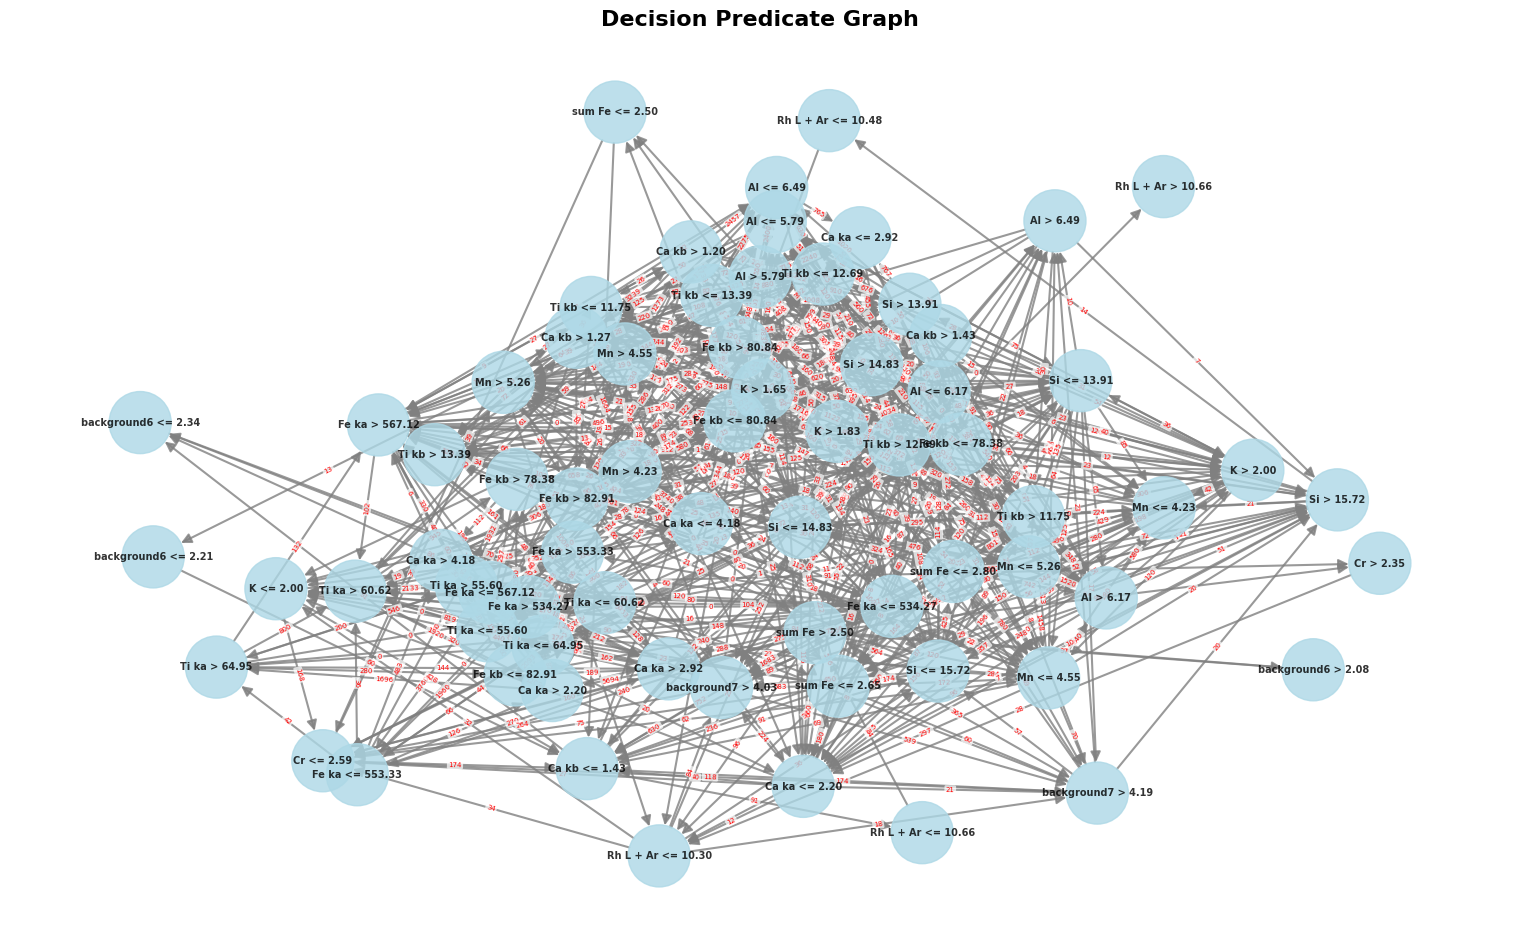

In [50]:
# Plotando o grafo final
import matplotlib.pyplot as plt
import networkx as nx

DG = graphs_by_seed[random_seeds[0]]  # usando o grafo da semente 42 como exemplo

# Layout hierárquico simples
pos = nx.spring_layout(DG, k=10, iterations=100, seed=42)

# Cores dos nós
colors = []
for node in DG.nodes():
    node_type = DG.nodes[node].get('node_type', 'predicate')
    if node_type == 'root_predicate':
        colors.append('green')
    elif node_type == 'terminal':
        colors.append('orange' if DG.nodes[node].get('class_label') == 'eut' else 'red')
    else:
        colors.append('lightblue')

# Preparar labels das arestas (pesos)
edge_labels = {(u, v): f"{DG[u][v]['weight']:.0f}" for u, v in DG.edges()}

# Plotando
plt.figure(figsize=(15, 9))
nx.draw(DG, pos, 
        node_color=colors,
        node_size=2000,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.5,
        alpha=0.8)

# Adicionar labels dos pesos nas arestas
nx.draw_networkx_edge_labels(DG, pos, 
                              edge_labels=edge_labels, 
                              font_size=5, 
                              font_color='red',
                              bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor='white', 
                                       edgecolor='none', 
                                       alpha=0.7))

plt.title('Decision Predicate Graph',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
# vamos conferir se existe alguma aresta com peso igual a zero 

zero_weight_edges_by_seed = {}

for seed in random_seeds:
    DG = graphs_by_seed[seed]
    zero_weight_edges = []
    
    for u, v, data in DG.edges(data=True):
        weight = data.get('weight', 0)
        if weight == 0:
            zero_weight_edges.append((u, v, weight))
    
    zero_weight_edges_by_seed[seed] = zero_weight_edges
    
    print(f"Semente {seed}:")
    print(f"  Total de arestas: {DG.number_of_edges()}")
    print(f"  Arestas com peso zero: {len(zero_weight_edges)}")
    
    if zero_weight_edges:
        print(f"  Exemplos de arestas com peso zero:")
        for u, v, w in zero_weight_edges[:5]:  # Mostrar até 5 exemplos
            print(f"    {u} -> {v} (peso: {w})")
    print()

# Resumo geral
total_zero_edges = sum(len(edges) for edges in zero_weight_edges_by_seed.values())
print(f"\nResumo Geral:")
print(f"  Total de arestas com peso zero em todas as sementes: {total_zero_edges}")

if total_zero_edges == 0:
    print("  ✓ Não existem arestas com peso zero em nenhum dos grafos!")
else:
    print("  ⚠ Existem arestas com peso zero que podem causar problemas em cálculos de centralidade.")

Semente 0:
  Total de arestas: 754
  Arestas com peso zero: 36
  Exemplos de arestas com peso zero:
    Fe ka > 534.27 -> Fe ka <= 534.27 (peso: 0.0)
    Fe ka <= 553.33 -> Fe ka > 553.33 (peso: 0.0)
    Ca ka > 4.18 -> Ca ka <= 4.18 (peso: 0.0)
    Ti ka > 64.95 -> Ti ka <= 64.95 (peso: 0.0)
    Ti ka > 64.95 -> Ti ka <= 60.62 (peso: 0.0)

Semente 1:
  Total de arestas: 786
  Arestas com peso zero: 43
  Exemplos de arestas com peso zero:
    Fe ka > 553.33 -> Fe ka <= 553.33 (peso: 0.0)
    Ca ka > 4.18 -> Ca ka <= 4.18 (peso: 0.0)
    Ti ka <= 60.62 -> Ti ka > 60.62 (peso: 0.0)
    Ti ka > 60.62 -> Ti ka <= 55.60 (peso: 0.0)
    Fe ka > 567.12 -> Fe ka <= 553.33 (peso: 0.0)


Resumo Geral:
  Total de arestas com peso zero em todas as sementes: 79
  ⚠ Existem arestas com peso zero que podem causar problemas em cálculos de centralidade.


In [52]:
# vamos calcular a LRC de acordo com as diferentes sementes
import networkx as nx

lrc_by_seed = {}
for seed in random_seeds:
    DG = graphs_by_seed[seed]
    local_reaching_centrality = {}
    for node in DG.nodes():
        try:
            lrc_value = nx.local_reaching_centrality(DG, node, weight='weight')
        except ZeroDivisionError:
            # Assign 0 when division by zero occurs (isolated node or terminal node)
            lrc_value = 0.0
        local_reaching_centrality[node] = lrc_value

    # Ordenar por LRC
    sorted_lrc = sorted(local_reaching_centrality.items(), key=lambda x: x[1], reverse=True)
    
    # Criar DataFrame com LRC
    lrc_df_seed = pd.DataFrame(sorted_lrc, columns=['Node', 'Local_Reaching_Centrality'])
    
    # Extrair informações dos predicados (zona, threshold, operador)
    zones = []
    thresholds = []
    operators = []
    
    for node in lrc_df_seed['Node']:
        if node.startswith('Class_'):
            zones.append(None)
            thresholds.append(None)
            operators.append(None)
        else:
            pred_row = predicates_quantiles[0][predicates_quantiles[0]['rule'] == node].iloc[0]
            zones.append(pred_row['zone'])
            thresholds.append(pred_row['thresholds'])
            operators.append(pred_row['operator'])
    
    lrc_df_seed['Zone'] = zones
    lrc_df_seed['Threshold'] = thresholds
    lrc_df_seed['Operator'] = operators
    lrc_df_seed['Seed'] = seed  # Adicionar coluna com a semente
    
    # Armazenar LRC
    lrc_by_seed[seed] = lrc_df_seed

# junando todas as colunas 'Node' de lrc_by_seed em um único dataframe

lrc_all_seeds_df = pd.DataFrame() # 
for seed in random_seeds:
    lrc_df_seed = lrc_by_seed[seed]
    lrc_df_seed = lrc_df_seed.rename(columns={
        'Node': f'Predicate_Seed_{seed}'
    })
    lrc_all_seeds_df = pd.concat([lrc_all_seeds_df, lrc_df_seed[[f'Predicate_Seed_{seed}']]], axis=1)

# vamos filtrar lrc_by_seed em cada semente para manter apenas as zonas espectrais únicas com maior LRC em um mesmo dataframe
lrc_unique_by_seed = {}
for seed, lrc_df in lrc_by_seed.items():
    lrc_unique_df = lrc_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
    lrc_unique_df = lrc_unique_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
    lrc_unique_by_seed[seed] = lrc_unique_df

lrc_all_seeds_df # exibindo o dataframe consolidado com predicados de todas as sementes   

,Predicate_Seed_0,Predicate_Seed_1
0,Fe ka <= 567.12,Fe ka <= 567.12
1,Fe ka > 534.27,Fe ka <= 553.33
2,Fe ka <= 553.33,Fe ka > 534.27
3,Ca ka > 4.18,Fe ka > 553.33
4,Ca ka > 2.92,Ca ka > 4.18
...,...,...
67,Cr > 2.35,background6 <= 2.34
68,Rh L + Ar <= 10.48,Rh L + Ar > 10.66
69,sum Fe <= 2.50,Rh L + Ar <= 10.66
70,background6 > 2.08,background7 <= 4.03


In [55]:
lrc_by_seed[0]

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator,Seed
0,Fe ka <= 567.12,0.0,Fe ka,567.12,<=,0
1,Fe ka > 534.27,0.0,Fe ka,534.27,>,0
2,Fe ka <= 553.33,0.0,Fe ka,553.33,<=,0
3,Ca ka > 4.18,0.0,Ca ka,4.18,>,0
4,Ca ka > 2.92,0.0,Ca ka,2.92,>,0
...,...,...,...,...,...,...
66,background6 <= 2.21,0.0,background6,2.21,<=,0
67,Cr > 2.35,0.0,Cr,2.35,>,0
68,Rh L + Ar <= 10.48,0.0,Rh L + Ar,10.48,<=,0
69,sum Fe <= 2.50,0.0,sum Fe,2.50,<=,0


In [53]:
features_importance = pd.DataFrame({
    'Vip' : vip_scores_unique_df['Zone'].iloc[:10].values,
    'Reg_coef' : reg_vet_unique_df['Zone'].iloc[:10].values
    })

for seed, lrc_unique_df in lrc_unique_by_seed.items():
    features_importance[f'LRC_Seed_{seed}'] = lrc_unique_df['Zone'].iloc[:10].values
features_importance.head(10)

,Vip,Reg_coef,LRC_Seed_0,LRC_Seed_1
0,Ca ka,Ca ka,Fe ka,Fe ka
1,Fe ka,Mn,Ca ka,Ca ka
2,Mn,Al,Ti ka,Fe kb
3,Ca kb,K,Fe kb,Ti ka
4,Fe kb,Ca kb,Mn,Mn
5,Al,P,Ca kb,Ca kb
6,K,Ti ka,Si,Ti kb
7,Ti ka,Si,Al,Al
8,P,Fe ka,Ti kb,Si
9,Si,Ti kb,K,K


In [54]:
# utilizando o Rank-Biased Overlap (RBO) para comparar as listas de importância de características tendo o vip como referencia
# com p = 1 é rbo equivalente ao overlap simples (interseção sobre união) sem peso para posições iniciais
# quanto menor o p, mais peso é dado para as posições iniciais da lista (mais relevante para nosso caso)
import rbo

rbo_results = {}
reference_list = features_importance['Vip'].tolist()
methods = ['Reg_coef'] + [f'LRC_Seed_{seed}' for seed in random_seeds]
for method in methods:
    compare_list = features_importance[method].tolist()
    score = rbo.RankingSimilarity(reference_list, compare_list).rbo(p=0.7, k=10) # o p=0.9 dá mais peso para as posições iniciais, k=10 limita a comparação às top 10 posições
    rbo_results[method] = score
rbo_results = pd.DataFrame(list(rbo_results.items()), columns=['Method', 'RBO_Score'])
rbo_results.insert(0, 'Reference', 'Vip')
rbo_results.sort_values(by='RBO_Score', ascending=False, inplace=True)
rbo_results

,Reference,Method,RBO_Score
0,Vip,Reg_coef,0.701290
1,Vip,LRC_Seed_0,0.530267
2,Vip,LRC_Seed_1,0.530267
